# Installing Libraries

The Required Libraries for the current process is loaded into the system by executing the following commands in a seperate python virtual environment's terminal:

```bash
pip install tqdm
pip install numpy
pip install pandas
pip install Pillow
pip install torch 
pip install torchvision 
pip install scikit-learn
```

The rest of the Libraries are already included in the python installation by default

# Importing Packages and Datasets

In [1]:
import torchvision.transforms as transforms
import torchvision.models as models
import torch.nn as nn
import torch

In [33]:
import matplotlib.pyplot as plt
from cycler import cycler
import pandas as pd
import numpy as np
import os

In [3]:
from sklearn.metrics import roc_auc_score, roc_curve
from torch.utils.data import DataLoader

In [4]:
from Datasets import ChestXrayDataset

# Device Setup

In [5]:
if torch.backends.mps.is_available():
    device = torch.device("mps")
elif torch.cuda.is_available():
    device = torch.device("cuda")
else:
    device = torch.device("cpu")

print(device)

mps


# Load Dataset

In [6]:
DATASET_PATH = "Dataset"
IMAGE_PATH = os.path.join(DATASET_PATH, "Images")

In [7]:
df = pd.read_csv(os.path.join(DATASET_PATH, "02. cleaned_dataset.csv"))

all_labels = set()
for labels_str in df["Finding Labels"]:
    for disease in labels_str.split("|"):
        all_labels.add(disease)

diseases = sorted(all_labels)

diseases

['Atelectasis',
 'Cardiomegaly',
 'Consolidation',
 'Edema',
 'Effusion',
 'Emphysema',
 'Fibrosis',
 'Hernia',
 'Infiltration',
 'Mass',
 'No Finding',
 'Nodule',
 'Pleural_Thickening',
 'Pneumonia',
 'Pneumothorax']

In [8]:
test_df = pd.read_csv("Dataset/03. test_df.csv")

# Transforms, Dataset, and Loaders

In [9]:
test_transforms = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.ToTensor(),
    transforms.Normalize([0.5],[0.5])
])

In [10]:
test_dataset = ChestXrayDataset(
    test_df,
    IMAGE_PATH,
    diseases,
    transform=test_transforms
)

In [11]:
test_loader = DataLoader(
    test_dataset,
    batch_size=32,
    shuffle=False,
    num_workers=0
)

# Loading Model

In [12]:
model = models.densenet121()

In [13]:
num_features = model.classifier.in_features
model.classifier = nn.Linear(num_features, len(diseases))

In [14]:
model.load_state_dict(torch.load("Models/best_model.pth", map_location=device))
model = model.to(device)

model.eval()

DenseNet(
  (features): Sequential(
    (conv0): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
    (norm0): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (relu0): ReLU(inplace=True)
    (pool0): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
    (denseblock1): _DenseBlock(
      (denselayer1): _DenseLayer(
        (norm1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (relu1): ReLU(inplace=True)
        (conv1): Conv2d(64, 128, kernel_size=(1, 1), stride=(1, 1), bias=False)
        (norm2): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (relu2): ReLU(inplace=True)
        (conv2): Conv2d(128, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      )
      (denselayer2): _DenseLayer(
        (norm1): BatchNorm2d(96, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (relu

# Inferences

In [15]:
all_preds = []
all_labels = []

In [16]:
with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)

        outputs = model(images)
        probs = torch.sigmoid(outputs)

        all_preds.append(probs.cpu().numpy())
        all_labels.append(labels.numpy())

In [17]:
all_preds = np.vstack(all_preds)
all_labels = np.vstack(all_labels)

# Compute AUROC Scores

In [18]:
auroc_scores = {}

In [19]:
for i, disease in enumerate(diseases):
    score = roc_auc_score(all_labels[:, i], all_preds[:, i])
    auroc_scores[disease] = score

In [20]:
for disease, score in auroc_scores.items():
    print(f"{disease}: {score:.3f}")

Atelectasis: 0.646
Cardiomegaly: 0.734
Consolidation: 0.630
Edema: 0.783
Effusion: 0.703
Emphysema: 0.699
Fibrosis: 0.748
Hernia: 0.896
Infiltration: 0.637
Mass: 0.567
No Finding: 0.597
Nodule: 0.662
Pleural_Thickening: 0.688
Pneumonia: 0.575
Pneumothorax: 0.696


In [21]:
mean_auroc = np.mean(list(auroc_scores.values()))
print("Mean AUROC:", mean_auroc)

Mean AUROC: 0.6838987240618398


# ROC Curve

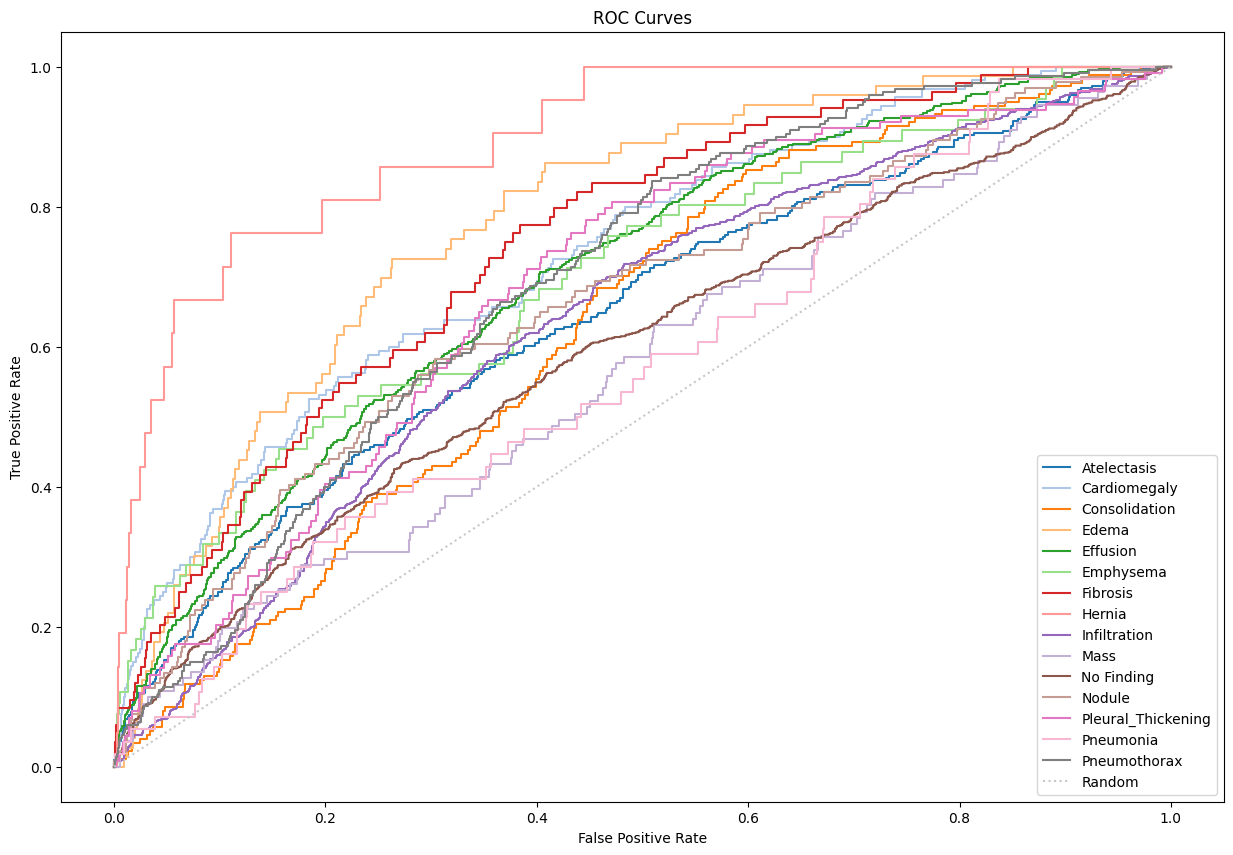

In [49]:
plt.figure(figsize=(15, 10))
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curves")

for i, disease in enumerate(diseases):
    fpr, tpr, _ = roc_curve(all_labels[:, i], all_preds[:, i])
    plt.plot(
        fpr, tpr,
        label=disease
    )

plt.rcParams['axes.prop_cycle'] = cycler(color=plt.cm.tab20.colors)
plt.plot([0,1],[0,1],':', label="Random")

plt.legend()
plt.show()

# Manual Testing

In [24]:
from PIL import Image

In [25]:
def predict_image(image_path):
    image = Image.open(image_path).convert("RGB")
    image = test_transforms(image)
    image = image.unsqueeze(0).to(device)

    with torch.no_grad():
        outputs = model(image)
        probs = torch.sigmoid(outputs)

    return probs.cpu().numpy()[0]

Atelectasis: 0.558
Cardiomegaly: 0.877
Consolidation: 0.336
Edema: 0.084
Effusion: 0.382
Emphysema: 0.491
Fibrosis: 0.472
Hernia: 0.681
Infiltration: 0.552
Mass: 0.524
No Finding: 0.674
Nodule: 0.496
Pleural_Thickening: 0.475
Pneumonia: 0.267
Pneumothorax: 0.461


(np.float64(-0.5), np.float64(1023.5), np.float64(1023.5), np.float64(-0.5))

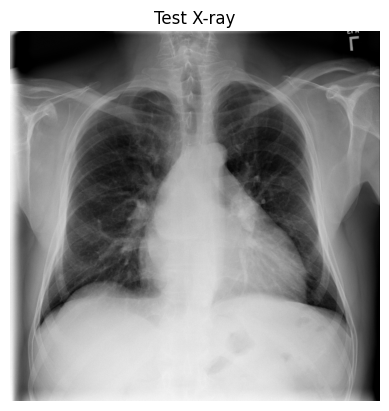

In [26]:
# Cardiomegaly
image_path = "Dataset/Images/00000001_000.png"
probs = predict_image(image_path)

for disease, prob in zip(diseases, probs):
    print(f"{disease}: {prob:.3f}")

img = Image.open(image_path)

plt.imshow(img, cmap="gray")
plt.title("Test X-ray")
plt.axis("off")

Atelectasis: 0.700
Cardiomegaly: 0.834
Consolidation: 0.743
Edema: 0.523
Effusion: 0.785
Emphysema: 0.725
Fibrosis: 0.324
Hernia: 0.382
Infiltration: 0.735
Mass: 0.816
No Finding: 0.391
Nodule: 0.643
Pleural_Thickening: 0.630
Pneumonia: 0.422
Pneumothorax: 0.789


(np.float64(-0.5), np.float64(1023.5), np.float64(1023.5), np.float64(-0.5))

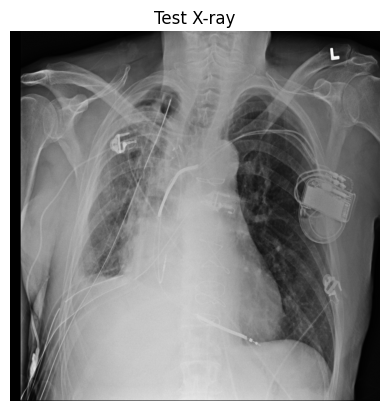

In [27]:
# Pneumothorax
image_path = "Dataset/Images/00000013_012.png"
probs = predict_image(image_path)

for disease, prob in zip(diseases, probs):
    print(f"{disease}: {prob:.3f}")

img = Image.open(image_path)

plt.imshow(img, cmap="gray")
plt.title("Test X-ray")
plt.axis("off")